In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats, optimize
from scipy.special import gammaln

In [3]:
DATA_DIR = Path("../data/CMAPSSData")
IMG_DIR = Path("../images")
IMG_DIR.mkdir(exist_ok=True)

In [4]:
COLS = ["unit", "cycle"] + [f"op_{i}" for i in range(1, 4)] + [f"s_{i}" for i in range(1, 22)]
def load(name):
    return pd.read_csv(DATA_DIR / name, sep=r"\s+", header=None, names=COLS, engine="python")
 
def lifespans(ds):
    tr = load(f"train_{ds}.txt")
    te = load(f"test_{ds}.txt")
    rul = pd.read_csv(DATA_DIR / f"RUL_{ds}.txt", header=None, names=["RUL"]).squeeze("columns").values
    life_tr = tr.groupby("unit").cycle.max().values.astype(float)
    life_te = (te.groupby("unit").cycle.max().values + rul).astype(float)
    return np.concatenate([life_tr, life_te])
 
lives = {ds: lifespans(ds) for ds in ["FD001", "FD002", "FD004"]}

In [5]:
# ---------- Single-Weibull fit per dataset ----------
def aic(logL, k): return 2 * k - 2 * logL
def weibull_mttf(beta, eta): return eta * np.exp(gammaln(1 + 1 / beta))
def weibull_Bp(beta, eta, p): return eta * (-np.log(1 - p)) ** (1 / beta)
 
print("=" * 78)
print("SINGLE-COMPONENT WEIBULL FITS")
print("=" * 78)
 
fits = {}
for ds, x in lives.items():
    beta, _, eta = stats.weibull_min.fit(x, floc=0)
    logL = stats.weibull_min.logpdf(x, beta, 0, eta).sum()
    ks_D, ks_p = stats.kstest(x, "weibull_min", args=(beta, 0, eta))
    fits[ds] = {"beta": beta, "eta": eta, "logL": logL, "n": len(x),
                "AIC": aic(logL, 2), "KS_D": ks_D, "KS_p": ks_p}
    print(f"  {ds}  n={len(x):3d}  β={beta:5.2f}  η={eta:6.1f}  "
          f"MTTF={weibull_mttf(beta,eta):6.1f}  B10={weibull_Bp(beta,eta,0.1):6.1f}  "
          f"KS p={ks_p:.3f}  AIC={aic(logL,2):7.1f}")

SINGLE-COMPONENT WEIBULL FITS
  FD001  n=200  β= 4.55  η= 224.8  MTTF= 205.3  B10= 137.0  KS p=0.001  AIC= 2116.8
  FD002  n=519  β= 4.48  η= 228.7  MTTF= 208.7  B10= 138.4  KS p=0.000  AIC= 5527.1
  FD004  n=497  β= 3.23  η= 277.7  MTTF= 248.9  B10= 138.5  KS p=0.001  AIC= 5766.7


In [6]:
# ---------- 2-component Weibull mixture (EM) — for FD004 ----------
def weibull_pdf(t, beta, eta):
    return (beta / eta) * (t / eta) ** (beta - 1) * np.exp(-(t / eta) ** beta)
 
def em_weibull_mixture(x, K=2, n_iter=200, tol=1e-6, seed=0):
    rng = np.random.default_rng(seed)
    n = len(x)
    # Init by splitting at median
    med = np.median(x)
    init_mask = x < med
    betas = np.array([3.0, 3.0])
    etas = np.array([np.mean(x[init_mask]) / np.exp(gammaln(1 + 1/3)),
                     np.mean(x[~init_mask]) / np.exp(gammaln(1 + 1/3))])
    pis = np.array([init_mask.mean(), 1 - init_mask.mean()])
 
    prev_ll = -np.inf
    for it in range(n_iter):
        # E step
        comp = np.stack([pis[k] * weibull_pdf(x, betas[k], etas[k]) for k in range(K)], axis=1)
        comp = np.clip(comp, 1e-300, None)
        gamma = comp / comp.sum(axis=1, keepdims=True)
 
        # M step: per component, weighted Weibull MLE via numerical root
        new_betas = np.zeros(K)
        new_etas = np.zeros(K)
        new_pis = gamma.mean(axis=0)
        for k in range(K):
            w = gamma[:, k]
            ws = w.sum()
            def score(b):
                xb = x ** b
                top = (w * xb * np.log(x)).sum()
                bot = (w * xb).sum()
                return top / bot - (w * np.log(x)).sum() / ws - 1 / b
            try:
                b_new = optimize.brentq(score, 0.3, 30.0)
            except ValueError:
                b_new = betas[k]
            eta_new = ((w * x ** b_new).sum() / ws) ** (1 / b_new)
            new_betas[k] = b_new
            new_etas[k] = eta_new
 
        betas, etas, pis = new_betas, new_etas, new_pis
        ll = np.log(np.stack([pis[k] * weibull_pdf(x, betas[k], etas[k])
                              for k in range(K)], axis=1).sum(axis=1)).sum()
        if abs(ll - prev_ll) < tol:
            break
        prev_ll = ll
 
    # Sort components by eta for reproducibility
    order = np.argsort(etas)
    return {"beta": betas[order], "eta": etas[order], "pi": pis[order],
            "logL": ll, "n_iter": it + 1, "gamma": gamma[:, order]}

In [7]:
print("\n" + "=" * 78)
print("2-COMPONENT WEIBULL MIXTURE — FD004")
print("=" * 78)
x4 = lives["FD004"]
mix = em_weibull_mixture(x4, K=2)
k_params = 5  # 2 betas + 2 etas + 1 pi (the other is 1-pi)
aic_mix = aic(mix["logL"], k_params)
aic_single = fits["FD004"]["AIC"]
print(f"  Component 1:  π={mix['pi'][0]:.2f}  β={mix['beta'][0]:.2f}  η={mix['eta'][0]:.1f}  "
      f"MTTF={weibull_mttf(mix['beta'][0], mix['eta'][0]):.1f}")
print(f"  Component 2:  π={mix['pi'][1]:.2f}  β={mix['beta'][1]:.2f}  η={mix['eta'][1]:.1f}  "
      f"MTTF={weibull_mttf(mix['beta'][1], mix['eta'][1]):.1f}")
print(f"  EM converged in {mix['n_iter']} iterations")
print(f"\n  Single Weibull:  logL={fits['FD004']['logL']:.1f}  AIC={aic_single:.1f}")
print(f"  2-comp mixture:  logL={mix['logL']:.1f}  AIC={aic_mix:.1f}")
print(f"  ΔAIC = {aic_single - aic_mix:+.1f}  "
      f"{'(mixture preferred)' if aic_mix < aic_single else '(single preferred)'}")


2-COMPONENT WEIBULL MIXTURE — FD004
  Component 1:  π=0.67  β=4.95  η=235.8  MTTF=216.4
  Component 2:  π=0.33  β=3.90  η=349.4  MTTF=316.2
  EM converged in 143 iterations

  Single Weibull:  logL=-2881.4  AIC=5766.7
  2-comp mixture:  logL=-2844.2  AIC=5698.3
  ΔAIC = +68.4  (mixture preferred)


In [8]:
# Bootstrap CI on FD004 mixture parameters (smaller B for speed)
print("\n  Bootstrapping mixture params (B=400)...")
rng = np.random.default_rng(42)
B = 400
boot = np.zeros((B, 5))
for i in range(B):
    sample = rng.choice(x4, size=len(x4), replace=True)
    try:
        m = em_weibull_mixture(sample, K=2, n_iter=80, seed=i)
        boot[i] = [m["pi"][0], m["beta"][0], m["eta"][0], m["beta"][1], m["eta"][1]]
    except Exception:
        boot[i] = np.nan
boot = boot[~np.isnan(boot).any(axis=1)]
ci = np.percentile(boot, [2.5, 97.5], axis=0)
for name, val, c in zip(["π1", "β1", "η1", "β2", "η2"],
                        [mix["pi"][0], mix["beta"][0], mix["eta"][0],
                         mix["beta"][1], mix["eta"][1]], ci.T):
    print(f"    {name} = {val:7.2f}   CI95 [{c[0]:7.2f}, {c[1]:7.2f}]")


  Bootstrapping mixture params (B=400)...
    π1 =    0.67   CI95 [   0.32,    0.81]
    β1 =    4.95   CI95 [   4.47,    9.13]
    η1 =  235.78   CI95 [ 194.39,  250.06]
    β2 =    3.90   CI95 [   3.64,    4.48]
    η2 =  349.38   CI95 [ 307.71,  385.75]


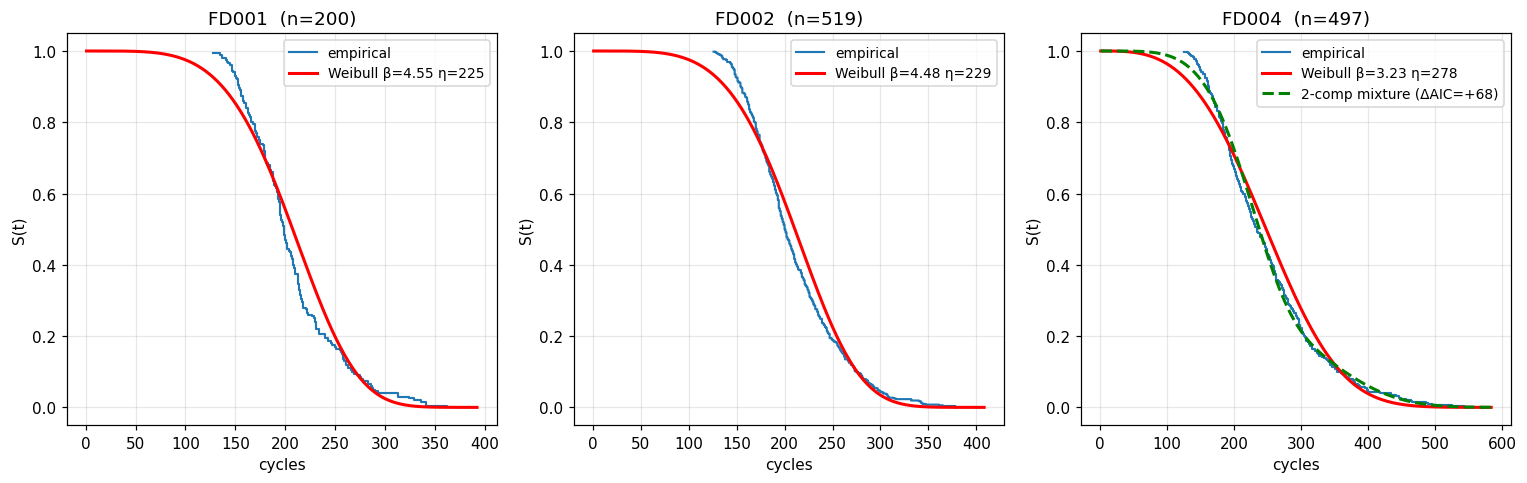

In [9]:
# ---------- Plots ----------
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
 
# 24. Survival curves: empirical + Weibull fit, 3 datasets side by side
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, ds in zip(axes, ["FD001", "FD002", "FD004"]):
    x = np.sort(lives[ds])
    S_emp = 1 - np.arange(1, len(x) + 1) / len(x)
    ax.step(x, S_emp, where="post", color="tab:blue", label="empirical", lw=1.4)
    t = np.linspace(1, x.max() + 30, 500)
    f = fits[ds]
    ax.plot(t, stats.weibull_min.sf(t, f["beta"], 0, f["eta"]),
            "r-", lw=2, label=f"Weibull β={f['beta']:.2f} η={f['eta']:.0f}")
    if ds == "FD004":
        S_mix = mix["pi"][0] * stats.weibull_min.sf(t, mix["beta"][0], 0, mix["eta"][0]) + \
                mix["pi"][1] * stats.weibull_min.sf(t, mix["beta"][1], 0, mix["eta"][1])
        ax.plot(t, S_mix, "g--", lw=2,
                label=f"2-comp mixture (ΔAIC={aic_single - aic_mix:+.0f})")
    ax.set_xlabel("cycles")
    ax.set_ylabel("S(t)")
    ax.set_title(f"{ds}  (n={len(x)})")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(IMG_DIR / "24_survival_3ds.png", bbox_inches="tight")
plt.show()
plt.close()

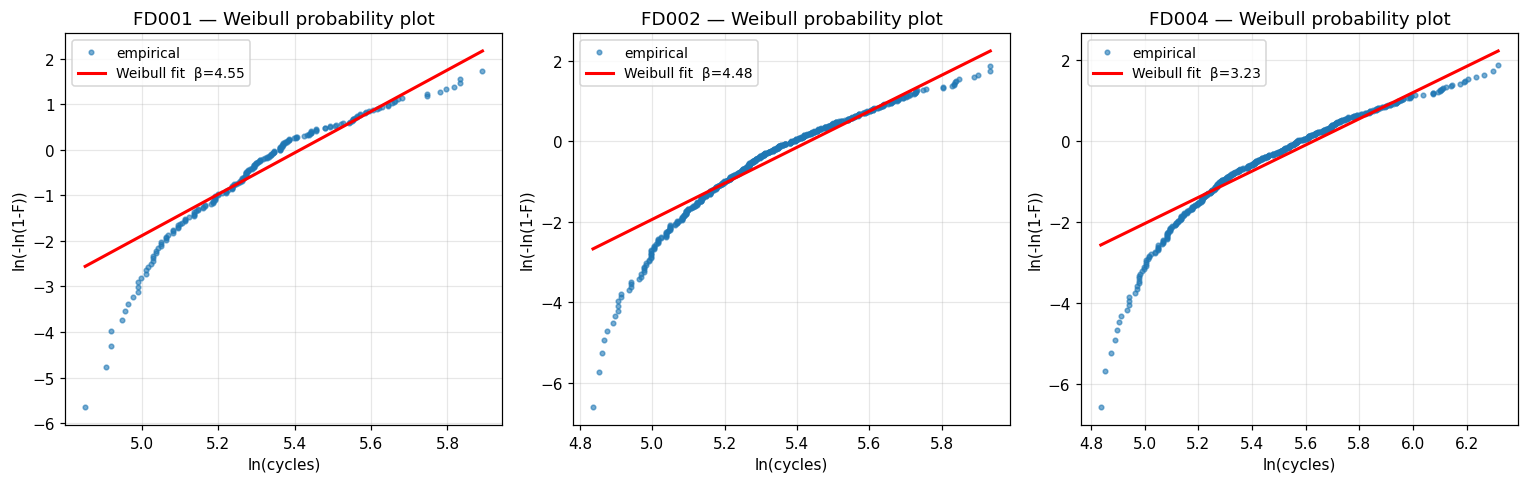

In [10]:
# 25. Weibull probability plot — 3 datasets
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, ds in zip(axes, ["FD001", "FD002", "FD004"]):
    x = np.sort(lives[ds])
    F = (np.arange(1, len(x) + 1) - 0.3) / (len(x) + 0.4)
    f = fits[ds]
    ax.plot(np.log(x), np.log(-np.log(1 - F)), "o", ms=3, alpha=0.6, label="empirical")
    xl = np.linspace(np.log(x).min(), np.log(x).max(), 50)
    ax.plot(xl, f["beta"] * (xl - np.log(f["eta"])), "r-", lw=2,
            label=f"Weibull fit  β={f['beta']:.2f}")
    ax.set_xlabel("ln(cycles)")
    ax.set_ylabel("ln(-ln(1-F))")
    ax.set_title(f"{ds} — Weibull probability plot")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(IMG_DIR / "25_probplot_3ds.png", bbox_inches="tight")
plt.show()
plt.close()

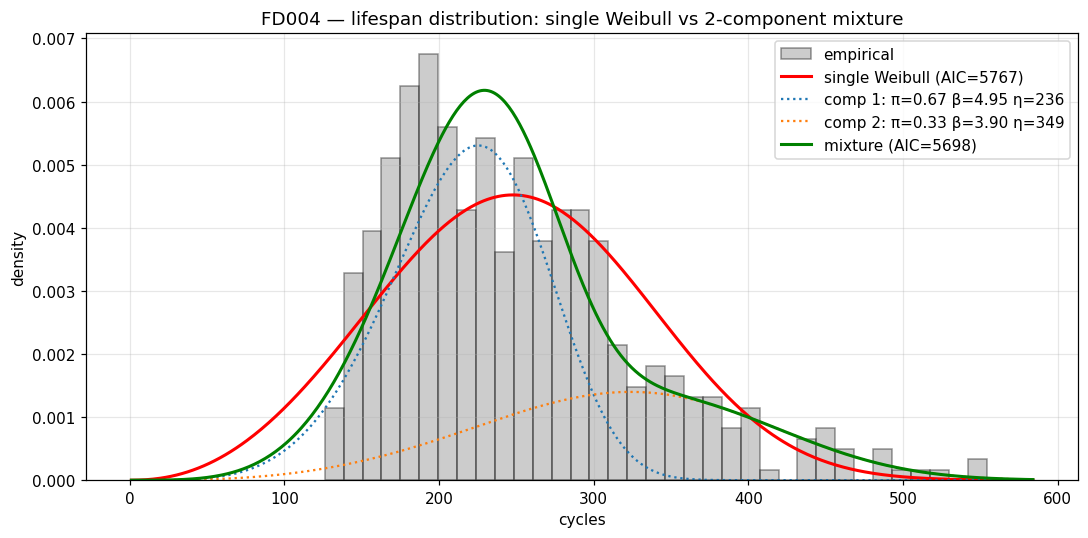

In [11]:
# 26. FD004 density with mixture components
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(x4, bins=35, density=True, alpha=0.4, color="gray",
        edgecolor="black", label="empirical")
t = np.linspace(1, x4.max() + 30, 500)
f = fits["FD004"]
ax.plot(t, stats.weibull_min.pdf(t, f["beta"], 0, f["eta"]),
        "r-", lw=2, label=f"single Weibull (AIC={aic_single:.0f})")
for k, c in enumerate(["tab:blue", "tab:orange"]):
    ax.plot(t, mix["pi"][k] * weibull_pdf(t, mix["beta"][k], mix["eta"][k]),
            color=c, ls=":", lw=1.5,
            label=f"comp {k+1}: π={mix['pi'][k]:.2f} β={mix['beta'][k]:.2f} η={mix['eta'][k]:.0f}")
mix_pdf = sum(mix["pi"][k] * weibull_pdf(t, mix["beta"][k], mix["eta"][k]) for k in range(2))
ax.plot(t, mix_pdf, "g-", lw=2, label=f"mixture (AIC={aic_mix:.0f})")
ax.set_xlabel("cycles")
ax.set_ylabel("density")
ax.set_title("FD004 — lifespan distribution: single Weibull vs 2-component mixture")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(IMG_DIR / "26_fd004_mixture.png", bbox_inches="tight")
plt.show()
plt.close()

In [12]:
# 27. Summary table as figure
summary = pd.DataFrame([
    {"dataset": ds, "N": f["n"], "β": round(f["beta"], 2), "η": round(f["eta"], 1),
     "MTTF": round(weibull_mttf(f["beta"], f["eta"]), 1),
     "B10": round(weibull_Bp(f["beta"], f["eta"], 0.1), 1),
     "KS p": round(f["KS_p"], 3), "AIC": round(f["AIC"], 1)}
    for ds, f in fits.items()
])
summary.to_csv("weibull_summary_multi.csv", index=False)
print("\nSummary table:")
print(summary.to_string(index=False))


Summary table:
dataset   N    β     η  MTTF   B10  KS p    AIC
  FD001 200 4.55 224.8 205.3 137.0 0.001 2116.8
  FD002 519 4.48 228.7 208.7 138.4 0.000 5527.1
  FD004 497 3.23 277.7 248.9 138.5 0.001 5766.7
